In [1]:
# Importing System
from MDToolkit.IO.read_file import lammps_dump_file_to_simulation

LAMMPS_dump_file_path = "/media/jrjoseph/Elements/projects/training/water_box_ls6/water_box_nvt_prod.out"

type_mapping = {
    1 : "O",
    2 : "H"
}

water_box_simulation = lammps_dump_file_to_simulation(LAMMPS_dump_file_path, type_mapping)

Processing frames:   0%|          | 0/20001 [00:00<?, ?frame/s]

In [2]:
import matplotlib.pyplot as plt

def plot_axial_density(
    density_data,
    axis="x",
    show_std=True,
    show_bulk_density=True,
    ax=None
):

    if ax is None:
        fig, ax = plt.subplots()

    x = density_data["bin_centers"]

    ax.plot(
        x,
        density_data["density_mean"],
        label="Density"
    )

    if show_std:
        ax.fill_between(
            x,
            density_data["density_mean"] - density_data["density_std"],
            density_data["density_mean"] + density_data["density_std"],
            alpha=0.3,
            label="Std Dev"
        )

    if show_bulk_density:

        mean_density = density_data["average_density"]

        ax.axhline(
            mean_density,
            color="k",
            linestyle="--",
            linewidth=2,
            zorder=10,
            label=f"Bulk Density ({mean_density:.3f})"
        )

        if "average_density_std" in density_data:

            std = density_data["average_density_std"]

            ax.axhspan(
                mean_density - std,
                mean_density + std,
                alpha=0.15,
                color="gray"
            )

            ax.axhspan(
            mean_density - std,
            mean_density + std,
            alpha=0.15,
            color="gray",
            label=f"Bulk Density Std Dev (±{std:.5f})"
            )

    bin_edges = density_data["bin_edges"]

    ax.set_xlim(
        bin_edges[0],
        bin_edges[-1]
    )

    ax.set_xlabel(f"{axis} (Å)")
    ax.set_ylabel("Density (g/cm³)")
    ax.legend()

    return ax

def plot_elemental_number_density(
    density_data,
    axis = "x",
    elements = None,
    show_std = True,
    std_label = "Std Dev",
    ax = None
):
    '''
    '''

    if ax is None:
        fig, ax = plt.subplots()

    profiles = density_data["elemental_number_density_mean"]

    if elements is None:
        elements = sorted(profiles.keys())

    for element in elements:

        ax.plot(
            density_data["bin_centers"],
            profiles[element],
            label = element
        )

        if show_std:

            std = density_data["elemental_number_density_std"][element]

            ax.fill_between(
            density_data["bin_centers"],
            profiles[element] - std,
            profiles[element] + std,
            alpha=0.2)

    bin_edges = density_data["bin_edges"]

    ax.set_xlabel(f"{axis} (Å)")
    ax.set_ylabel("Normalized Number Density")
    ax.legend()
    ax.set_xlim(
        bin_edges[0],
        bin_edges[-1]
    )

    return ax

In [3]:
from MDToolkit.analysis.density import  averaged_axial_density

chosen_axis = "x"

density = averaged_axial_density(water_box_simulation, axis=chosen_axis, bins = 250)


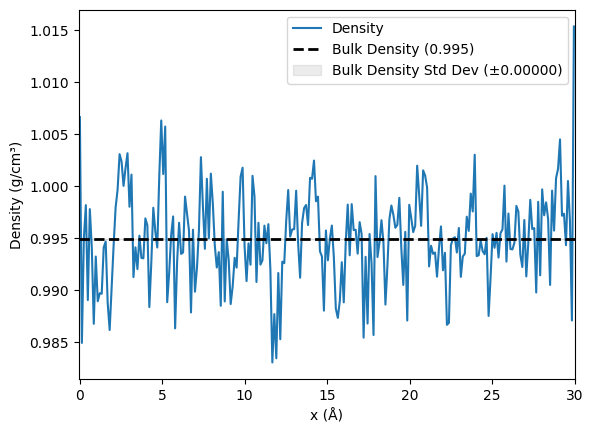

In [4]:
ax = plot_axial_density(density, axis = chosen_axis, show_std=False)
plt.show()

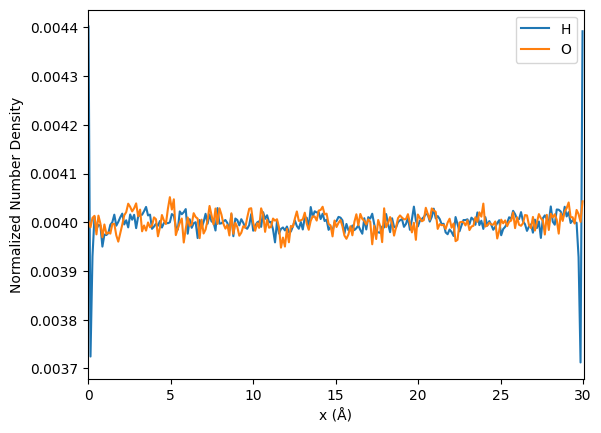

In [5]:
plot_elemental_number_density(density, show_std=False)
plt.show()